Cluster labels: [1 1 1 0 0 0]


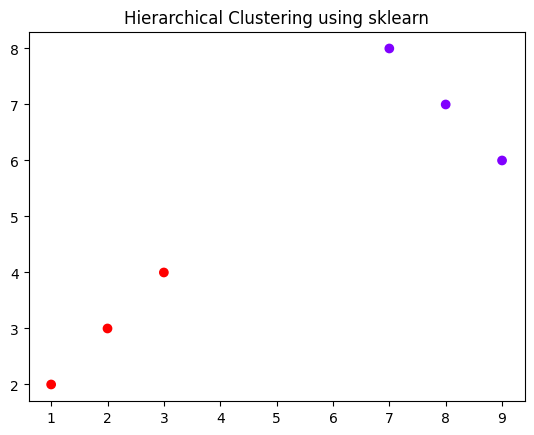

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Sample dataset
X = np.array([
    [1,2],
    [2,3],
    [3,4],
    [8,7],
    [7,8],
    [9,6]
])

# Apply hierarchical clustering
model = AgglomerativeClustering(n_clusters=2)

labels = model.fit_predict(X)

print("Cluster labels:", labels)

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title("Hierarchical Clustering using sklearn")
plt.show()


In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Dataset
X = np.array([
    [1,2],
    [2,3],
    [3,4],
    [8,7],
    [7,8],
    [9,6]
])

# Calculate distance matrix
dist_matrix = squareform(pdist(X, metric='euclidean'))

print("Distance Matrix:")
print(dist_matrix)

clusters = [[i] for i in range(len(X))]

while len(clusters) > 2:
    min_dist = float('inf')
    merge_pair = (0,0)

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            for a in clusters[i]:
                for b in clusters[j]:
                    if dist_matrix[a][b] < min_dist:
                        min_dist = dist_matrix[a][b]
                        merge_pair = (i,j)

    clusters[merge_pair[0]] += clusters[merge_pair[1]]
    clusters.pop(merge_pair[1])

print("Final Clusters:", clusters)


Distance Matrix:
[[0.         1.41421356 2.82842712 8.60232527 8.48528137 8.94427191]
 [1.41421356 0.         1.41421356 7.21110255 7.07106781 7.61577311]
 [2.82842712 1.41421356 0.         5.83095189 5.65685425 6.32455532]
 [8.60232527 7.21110255 5.83095189 0.         1.41421356 1.41421356]
 [8.48528137 7.07106781 5.65685425 1.41421356 0.         2.82842712]
 [8.94427191 7.61577311 6.32455532 1.41421356 2.82842712 0.        ]]
Final Clusters: [[0, 1, 2], [3, 4, 5]]


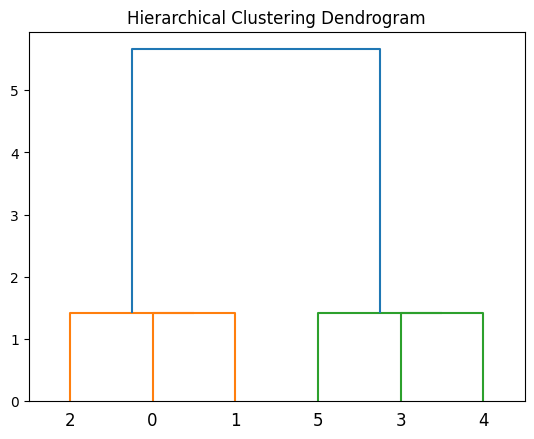

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='single')

dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()